In [91]:
#1. IMPORTS

from Bio import AlignIO 
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import random
import scipy

genes_occurence_matrix = np.loadtxt("/home/tommaso_cappelli_05/bzrs/ecoli_samples/ecoli_geneMatrix.txt", skiprows=1, usecols=range(1, 93))

#this is the matrix that gives us the number of occurences of each gene in the different species
#on the columns, same species; on the rows, same gene.

#the

11891


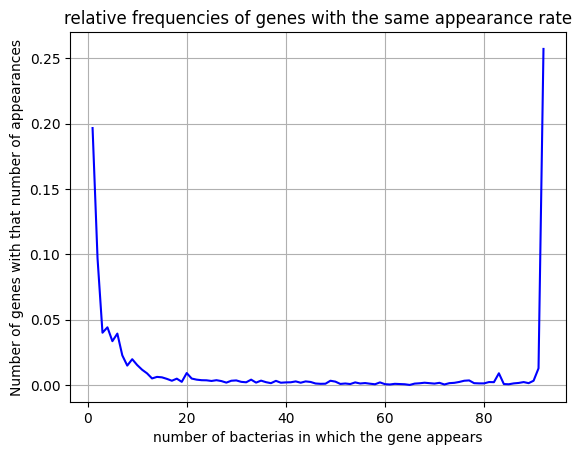

In [92]:
#2. EVALUATING THE PERCENTAGE OF OCCURRENCES FOR EACH GENE (ACCESSORY AND CORE) COMPARED TO THE TOTAL NUMBER OF BACTERIAS

#when we do this job, we have to get the matrix with the occurrences of each gene for each bacteria

genes_occurence_matrix = np.loadtxt("/home/tommaso_cappelli_05/bzrs/ecoli_samples/ecoli_geneMatrix.txt", skiprows=1, usecols=range(1, 93))
num_bacteria = len(genes_occurence_matrix[0,:])
n_genes = len(genes_occurence_matrix) #the number of genes is the same as number of rows
print(n_genes)
#gene_frequency = np.sum(genes_occurence_matrix, axis = 0) #it is already a row vector, but its max goes over the number of bacteria, since
#there is going to be some genes with multiple occurrences in lots of bacterias, therefore, what we would want to do is to convert
#each 2-3-4 to a single one

genes_occurence_matrix_boolean = np.bool(genes_occurence_matrix) #this tells us is a gene is actually present or not

genes_frequency_boolean = np.sum(genes_occurence_matrix_boolean, axis=1) #we keep this as an absolute frequency:
#the number indicates in how many bacterias out of the 92 species a gene appears


unique_genes_frequencies_boolean, counter_genes_samebooleanfreq= np.unique(genes_frequency_boolean, return_counts = True)


counter_genes_samebooleanfreq = counter_genes_samebooleanfreq / n_genes #this is the relative frequency>: how many genes
#appears that number of times compared to the total number of genes

plt.figure(1)
plt.plot(unique_genes_frequencies_boolean, counter_genes_samebooleanfreq, color = 'blue')
plt.title('relative frequencies of genes with the same appearance rate')
plt.xlabel('number of bacterias in which the gene appears')
plt.ylabel('Number of genes with that number of appearances')
plt.grid(visible = 'True')
plt.show()

#every bacteria that appears at least once 

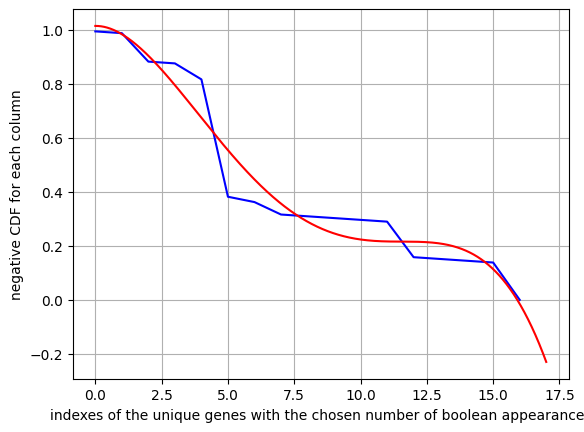

In [ ]:
#3. CHOSEN A NUMBER OF OCCURRENCIES, print the negative cumulative density function for the unique genes with that exact
#number of occurencies.

while True:
    try:
        to_be_tested =int(input("What's the number of gene appearances you want to check?"))
        if 0<to_be_tested<num_bacteria: #doesn't make sense to select 92, since you can have only 1 pattern, which will be 
            #1111111111111111111111111111111111111111
            break
        else:
            raise ValueError
    except ValueError:
        print(f'The number of gene appearances must be an integer between 1 and {num_bacteria}')
        
to_be_tested_indexes = genes_frequency_boolean == to_be_tested

test_boolean_matrix = genes_occurence_matrix_boolean[to_be_tested_indexes, :] #still 92 bases

unique_gene_patterns, gene_patterns_frequencies = np.unique(test_boolean_matrix, axis = 0, return_counts = True)
#if I put axis =1, the number of bacteria reduces, not the number of genes, therefore I'm going on
#the wrong way. Axis = 0
#here we will have all the unique gene patterns with the same frequencies

unique_gene_patterns_indexes = range(0, len(unique_gene_patterns))
gene_patterns_nCDF = 1 - np.cumsum(gene_patterns_frequencies / len(test_boolean_matrix)) #the length of the test matrix
#indicates the total number of genes with that frequency of appearance

#let's try to fit through a polynomial functionwhat we have here

poly_coeff = np.polyfit(unique_gene_patterns_indexes, gene_patterns_nCDF, 4)

poly_values = np.polyval(poly_coeff, np.linspace(0, len(unique_gene_patterns), 10000))
#no sense to implement a power-log, just too steep for these values.
#3 is probably the ideal polynomial grade in order to catch steep falls without having issues such as 

plt.figure(3)
plt.plot(unique_gene_patterns_indexes, gene_patterns_nCDF, color = 'blue')
plt.plot(np.linspace(0, len(unique_gene_patterns), 10000), poly_values, color = 'red')
plt.title('')
plt.xlabel('indexes of the unique genes with the chosen number of boolean appearances') 
plt.ylabel('negative CDF for each column')
plt.grid(visible = 'True')
plt.legend
plt.show()

#n = 2, linear nCDF ->uniform distribution

Text(0, 0.5, 'number of sorted distances')

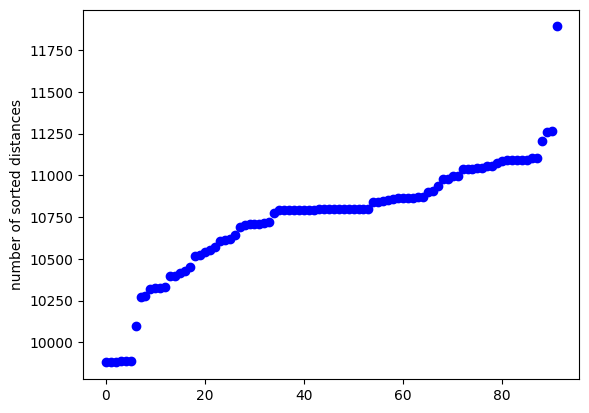

In [ ]:
#4. BY PICKING 1 SPECIES, calulcate the genome distances with each other and compare those with the SNP distances from the
#first exercise. COmpute then a plot for a bacteria with the distances from all the others

while True:
    try:
        index_ecoli =int(input("Which E. Coli species do you want to check?"))
        if 1<to_be_tested<num_bacteria: 
            break
        else:
            raise ValueError
    except ValueError:
        print(f'The index of your E. Coli species must be an integer between 1 and {num_bacteria}')
        
genome_to_test = genes_occurence_matrix[:, index_ecoli-1]

distances_from_testing_genome = []
for i in range(0, num_bacteria):
    
    distances_from_testing_genome.append(int(np.sum(genome_to_test == genes_occurence_matrix[:, i])))

#now we will have to import the other matrix from the ex.1 and calculate for each genome the SNP distance to the others.



In [88]:
#PRINTING TESTS

print(distances_from_testing_genome)




[10073, 10543, 10541, 11359, 11891, 10871, 10312, 10737, 11104, 11046, 10498, 9942, 10834, 10164, 10434, 10419, 9940, 10612, 10835, 10834, 10833, 10827, 10433, 10614, 10830, 10836, 10431, 9940, 10830, 9938, 9935, 10830, 10581, 10583, 10827, 10829, 10829, 10640, 10578, 11032, 11024, 10719, 10453, 11029, 11134, 11029, 10634, 11030, 10630, 10991, 10623, 10841, 11027, 10903, 10985, 11134, 10940, 10624, 10986, 11020, 11076, 10831, 10641, 10748, 10810, 10832, 10417, 10812, 10831, 11008, 10828, 10864, 10827, 11154, 10833, 10434, 10836, 11163, 11155, 11009, 11124, 11005, 11129, 11012, 11005, 10917, 10502, 10914, 10910, 11012, 10871, 10925]
